<p>
    <a href="https://umt.edu.al/en/anxhelo-shehu/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2022/10/Anxhelo-Shehu-min-2-300x300.jpg" width="150" alt="UMT Logo">
    </a>
</p>
<p>
    <a href="https://umt.edu.al/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2024/11/Universiteti-Metropolitan-Tirana.webp" width="200" alt="UMT Logo">
    </a>
</p>


<h1> Operacione Gjeometrike dhe Veprime të Tjera Matematike per  PDI</h1>

Koha e nevojshme e percaktuar: **+30** minuta

<h2>Objectivat</h2>

<ul>
    <li><a href='#PT'> Operacione Gjeometrike </a>
</ul>




</ul>
    <li><a href='#PT'> Operacione Matematike </a>
</ul>



Shkarkojme imazhet e nevojshme per kete **Lab** (lejohet edhe perdorimi i imazheve te tjera)

In [1]:
import requests

# URLs for the images
urls = [
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/mammogram.png"
]

# Shkarkojme edhe ruajm imazhet duke perdorur URL perkatese
for url in urls:
    response = requests.get(url)
    if response.status_code == 200:
        filename = url.split("/")[-1]
        with open(filename, 'wb') as file:
            file.write(response.content)
        print(f"Downloaded: {filename}")
    else:
        print(f"Failed to download: {url}")

Downloaded: lenna.png
Downloaded: baboon.png
Downloaded: mammogram.png


 Per kete Lab do te perdorim keto funksione:

In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

Për herë të parë, le të definojmë një funksion ndihmës për të vizualizuar dy imazhe krah për krah. Nuk është e nevojshme ta kuptoni këtë kod në këtë moment, por ky funksion do të përdoret vazhdimisht në këtë tutorial për të shfaqur rezultatet.

In [3]:
def plot_image(image_1, image_2,title_1="Im.Origjinal", title_2="Imazhi i Ri"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1,cmap="gray")
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2,cmap="gray")
    plt.title(title_2)
    plt.show()

Shumzimi:
lexojme 2 imazhet, lenna dhe babbon, edhe bejm shumzimin e tyre me.

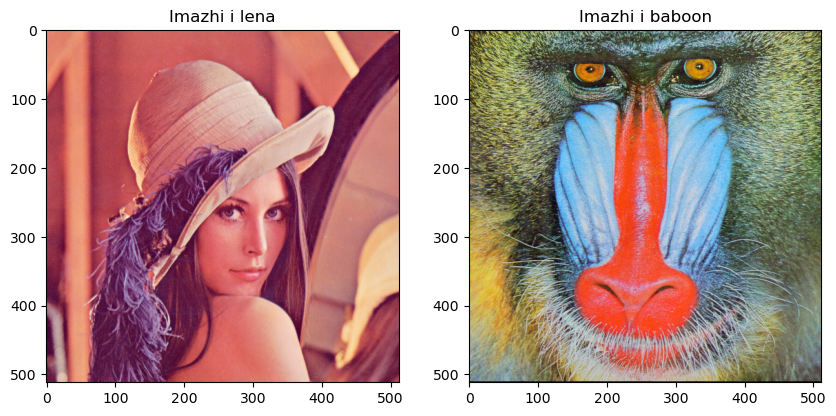

In [4]:
# Lexo imazhin
image1 = cv2.imread("lenna.png", ) 
image2 = cv2.imread("baboon.png")

# Shfaq imazhin
plot_image(cv2.cvtColor(image1,cv2.COLOR_BGR2RGB), cv2.cvtColor(image2,cv2.COLOR_BGR2RGB),title_1="Imazhi i lena", title_2="Imazhi i baboon")


Kontrrollojme dimensionet e tyre.


In [5]:
print(image1.shape, image2.shape)

(512, 512, 3) (512, 512, 3)


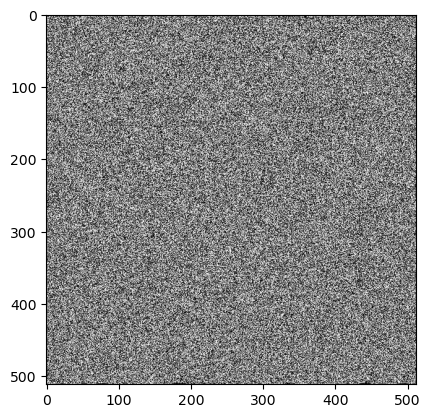

In [6]:
image_new = image1[:,:,1]*image2[:,:,1]
plt.imshow(image_new, cmap="gray")

Shumzimi me dimensione te ndryshme:
    

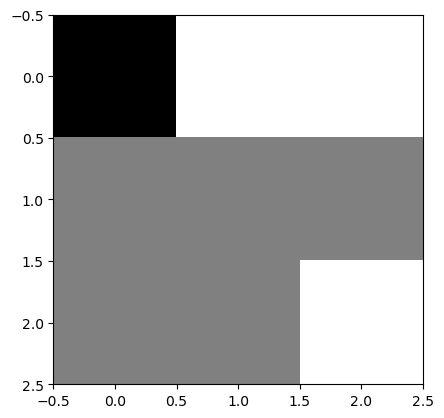

Imazh_shembull: [[0 2 2]
 [1 1 1]
 [1 1 2]]


In [7]:
shembull_imazh = np.array([[0,2,2],[1,1,1],[1,1,2]],dtype=np.uint8)
plt.imshow(shembull_imazh, cmap="gray")
plt.show()
print("Imazh_shembull:",shembull_imazh)

In [8]:
image_new = image1[:,:,0]*shembull_imazh
plt.imshow(image_new, cmap="gray")

ValueError: operands could not be broadcast together with shapes (512,512) (3,3) 

## Pra kemi kete problem `ValueError: operands could not be broadcast together with shapes (512,512) (3,3)`

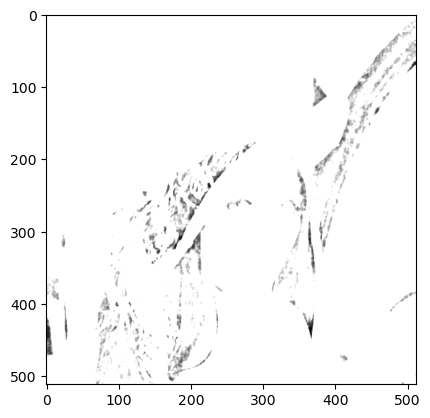

(512, 512)


In [9]:
# Apliko filtrin me konvolucion
image_new = cv2.filter2D(image1[:,:,1], -1, shembull_imazh)

# Shfaq imazhin e ri
plt.imshow(image_new, cmap="gray")
plt.show()
print(image_new.shape)

# Ndrryshimi i variances per imazhet 

### **Modifikimi i Variancës së një Imazhi**

Për të modifikuar një imazh duke shumëzuar variancën e tij me faktorë të ndryshëm (**0.01, 0.25, 0.5, 2, 5, 30**), mund të përdorim formulën:

$$
I' = \mu + k \cdot (I - \mu)
$$

ku:  
- $I'$ është imazhi i modifikuar,  
- $I$ është imazhi origjinal,  
- $\mu$ është mesatarja e pixelëve,  
- $k$ është faktori me të cilin ndryshojmë variancën.


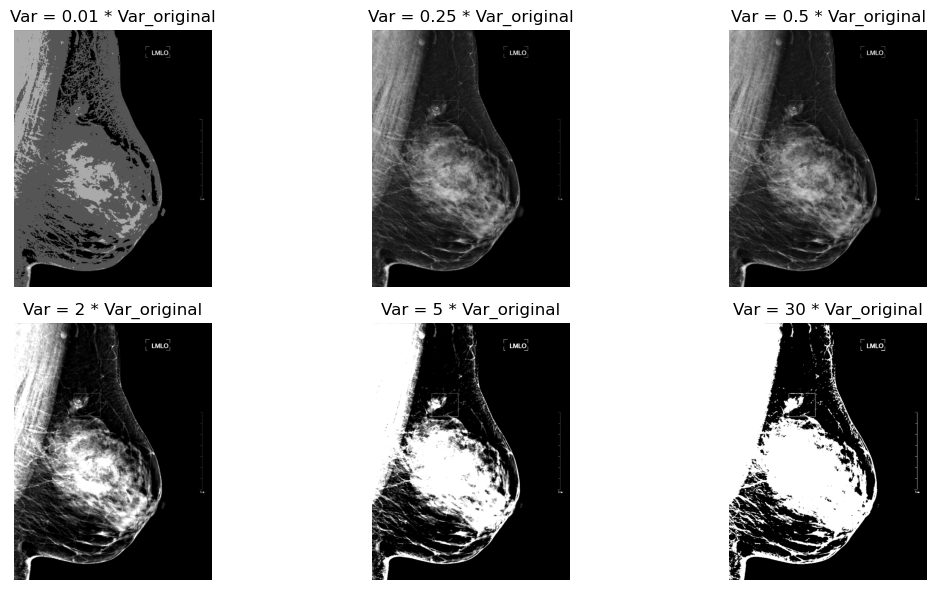

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Lexo imazhin në shkallë gri
#image = cv2.imread("m.png", cv2.IMREAD_GRAYSCALE)
image = cv2.imread("mammogram.png", cv2.IMREAD_GRAYSCALE)

# Llogarit mesataren dhe devijimin standard
mean, std = np.mean(image), np.std(image)

# Faktorët e ndryshimit të variancës
factors = [0.01, 0.25, 0.5, 2, 5, 30]

# Krijo figura për të shfaqur imazhet
plt.figure(figsize=(12, 6))

for i, k in enumerate(factors):
    # Ndrysho variancën
    modified_image = mean + k * (image - mean)

    # Sigurohu që pixelët janë në intervalin [0, 255]
    modified_image = np.clip(modified_image, 0, 255).astype(np.uint8)

    # Shfaq imazhin e modifikuar
    plt.subplot(2, 3, i + 1)
    plt.imshow(modified_image, cmap='gray')
    plt.title(f"Var = {k} * Var_original")
    plt.axis("off")

# Shfaq të gjitha imazhet
plt.tight_layout()
plt.show()


# Shembull: Shtimi i imazheve të zhurmshme për reduktimin e zhurmës

### Imazhi pa zhurmë:
$$ f(x,y) $$

### Zhurma:
$$ n(x,y) $$  
(në çdo çift koordinatash (x,y), zhurma është e pakorreluar dhe ka vlerë mesatare zero)

### Imazhi i korruptuar (modifikuar):
$$ g(x,y) = f(x,y) + n(x,y) $$

---

### Reduktimi i zhurmës duke shtuar një grup imazhesh me zhurmë:

Për një grup imazhesh të zhurmshme $$ \{ g_i (x,y) \} $$:

$$
\overline{g(x,y)} = \frac{1}{K} \sum_{i=1}^{K} g_i(x,y)
$$

---



(525, 875)


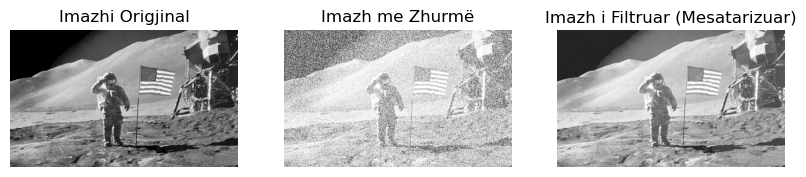

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Funksioni për të shtuar zhurmë Gaussian në një imazh
def add_gaussian_noise(image, mean=0, sigma=40):
    noise = np.random.normal(mean, sigma, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, noise)  # Siguron që vlerat të jenë në intervalin e duhur
    return noisy_image

# Lexo imazhin në grayscale
image = cv2.imread("nasa.png", cv2.IMREAD_GRAYSCALE)
print(image.shape)
# Numri i imazheve që do të mesatarizohen
num_images = 400
noisy_images = []

# Krijo disa versione të zhurmshme të imazhit
for _ in range(num_images):
    noisy_image = add_gaussian_noise(image)
    noisy_images.append(noisy_image)

# Mesatarizo të gjitha imazhet
average_image = np.mean(noisy_images, axis=0).astype(np.uint8)

# Shfaq rezultatet
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.title("Imazhi Origjinal")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Imazh me Zhurmë")
plt.imshow(noisy_images[1], cmap="gray")  # Shfaq njërin nga imazhet me zhurmë
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Imazh i Filtruar (Mesatarizuar)")
plt.imshow(average_image, cmap="gray")
plt.axis("off")

plt.show()


# Një shembull i zbritjes së imazhit: MRI e mushkris dhe maska per ROI

### Maska $$ h(x,y) $$  


### Imazhe të drejtpërdrejta $$ f(x,y) $$  
Imazhet me rreze X i mushkris

### Identifikimi i zones $$ g(x,y) $$  
$$
g(x,y) = f(x,y) - h(x,y)
$$

---


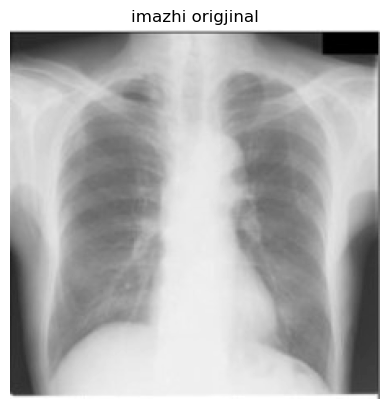

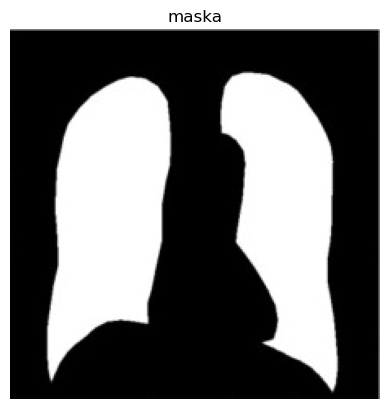

In [23]:
import cv2
import numpy as np

# Lexo imazhin origjinal dhe maskën në shkallë gri
orig_img = cv2.imread("skaner.jpg", cv2.IMREAD_GRAYSCALE)
mask_img = cv2.imread("skaner_mask.jpg", cv2.IMREAD_GRAYSCALE)
# Shfaq imazhin e përpunuar
plt.title("imazhi origjinal")
plt.imshow(orig_img, cmap="gray")
plt.axis("off")
plt.show()
# Shfaq imazhin e përpunuar
plt.title("maska")
plt.imshow(mask_img, cmap="gray")
plt.axis("off")
plt.show()



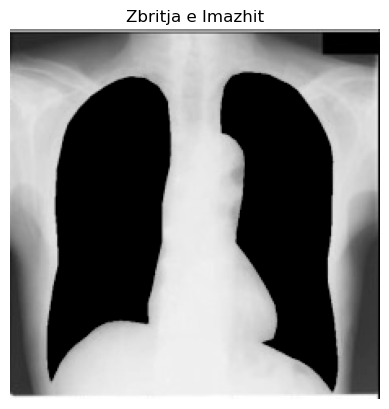

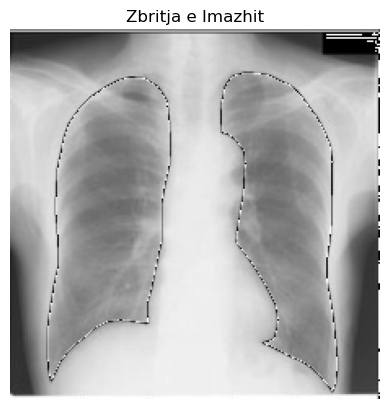

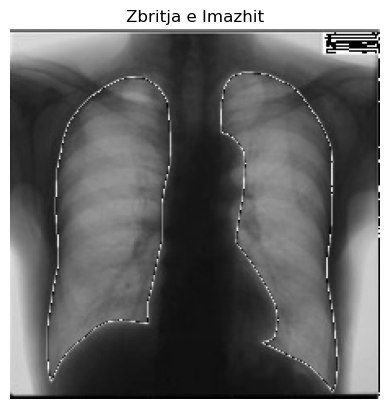

In [24]:

# Zbrit imazhin maskë nga imazhi origjinal
result_img = cv2.subtract(orig_img, mask_img)
orgminusmask = orig_img - mask_img
maskminusorg = mask_img - orig_img
# Ruaj rezultatin
cv2.imwrite("result.jpg", result_img)

# Shfaq imazhin e përpunuar
plt.title("Zbritja e Imazhit")
plt.imshow(result_img, cmap="gray")
plt.axis("off")
plt.show()
# Shfaq imazhin e përpunuar
plt.title("Zbritja e Imazhit")
plt.imshow(orgminusmask, cmap="gray")
plt.axis("off")
plt.show()
# Shfaq imazhin e përpunuar
plt.title("Zbritja e Imazhit")
plt.imshow(maskminusorg, cmap="gray")
plt.axis("off")
plt.show()

---

# Ushtrim për Perpunimin e imazhev

1. **Shkarkimi i Imazhit**:
   - Shkarkohet një imazh në formatin RGB nga interneti(imazh te nje bime te demtuar, ose nje maceje)

2. **Ndryshimi i Dimensioneve të Imazhit**:
   - Të zvogëlohen ose të rriten dimensionet e imazhit në masën 225x225 duke përdorur interpolimin kuadratik.

3. **Konvertimi në Formatin Bardh e Zi**:
   - Të konvertohet imazhi në formatin bardh e zi si një mesatare e vlerave të pikselave RGB.

4. **Ndryshimi i Variancës**:
   - Duke përdorur metodat probabilistike, të ndryshohet vlera e variancës në 0.5*var dhe 50*var.
   
5. **Shtimi i imazheve të zhurmshme për reduktimin e zhurmës**:
   - Te behet shtimi i 50 imazheve te zhurmeshme per reduktimin e zhurmes*.

5. **Zbritja e imazhit me masken**:
   - Te zbritet imazhi original ne piken 3) me imazhin e supozuar mask nga pika 4) (si 50*var)*.
   
 -----

# Referenca

[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<h3 align="center"> &#169; UMT. All rights reserved. <h3/>